# Лабораторная работа №6

>Вариант: 9
> [Датасет про диабет](https://www.kaggle.com/datasets/abdallamahgoub/diabetes/data)

Импортируем необходимые библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import random
from itertools import combinations

pd.options.mode.chained_assignment = None
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

Для начала загрузим датасет и выведем его

In [2]:
file_id = "15vitm5WHBI-qP3TQn0KtFz6gyyHZC8Cj"
url = f"https://drive.google.com/uc?id={file_id}"
df = pd.read_csv(url)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


Рассчитаем основные статистические показатели по данным

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   Pedigree       768 non-null    float64
 7   Age            768 non-null    int64  
 8   Outcome        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'Pedigree'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

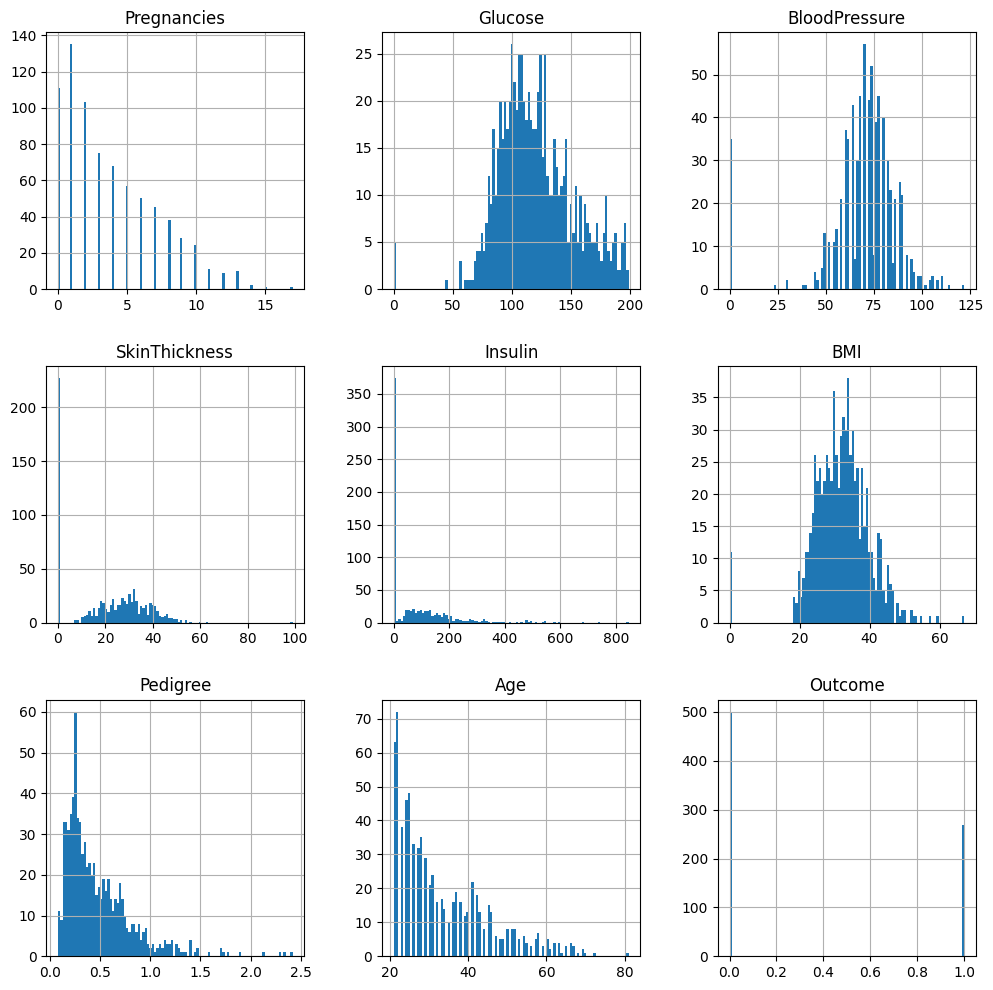

In [5]:
df.hist(bins=100, figsize=(12, 12))

Заменим отсутсвующие значения. Явный nan тут нет, однако для признаков `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI` нули равносильны пропускам. Удалим эти значения.

In [6]:
cols_zero_as_nan = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
df[cols_zero_as_nan] = df[cols_zero_as_nan].replace(0, np.nan)
df = df.dropna()

Повторим вывод графиков и статистики чтобы убедится в том что нули устранены

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,3.301020,122.627551,70.663265,29.145408,156.056122,33.086224,0.523046,30.864796,0.331633
std,3.211424,30.860781,12.496092,10.516424,118.841690,7.027659,0.345488,10.200777,0.471401
min,0.000000,56.000000,24.000000,7.000000,14.000000,18.200000,0.085000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,21.000000,76.750000,28.400000,0.269750,23.000000,0.000000
50%,2.000000,119.000000,70.000000,29.000000,125.500000,33.200000,0.449500,27.000000,0.000000
75%,5.000000,143.000000,78.000000,37.000000,190.000000,37.100000,0.687000,36.000000,1.000000
max,17.000000,198.000000,110.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'Pedigree'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

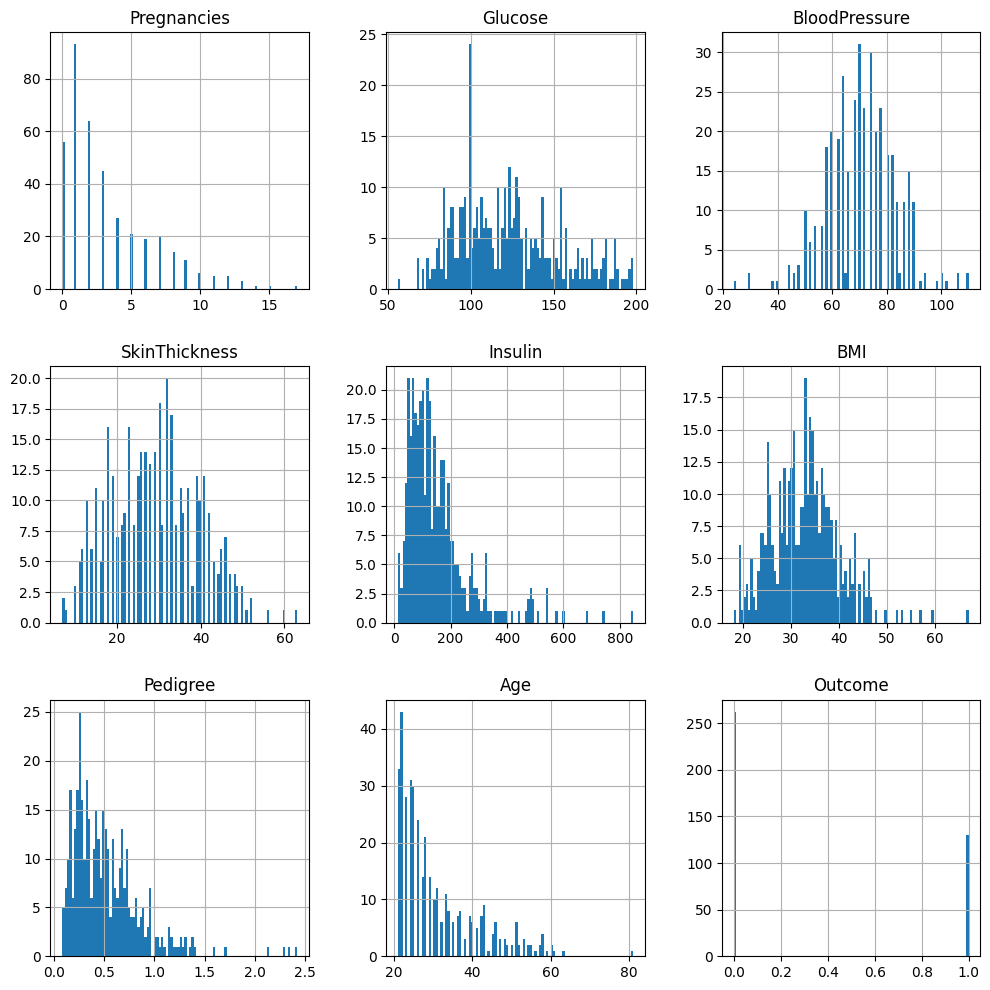

In [8]:
df.hist(bins=100, figsize=(12, 12))

Теперь построим box-plot чтобы проанализировать датасет на выбросы

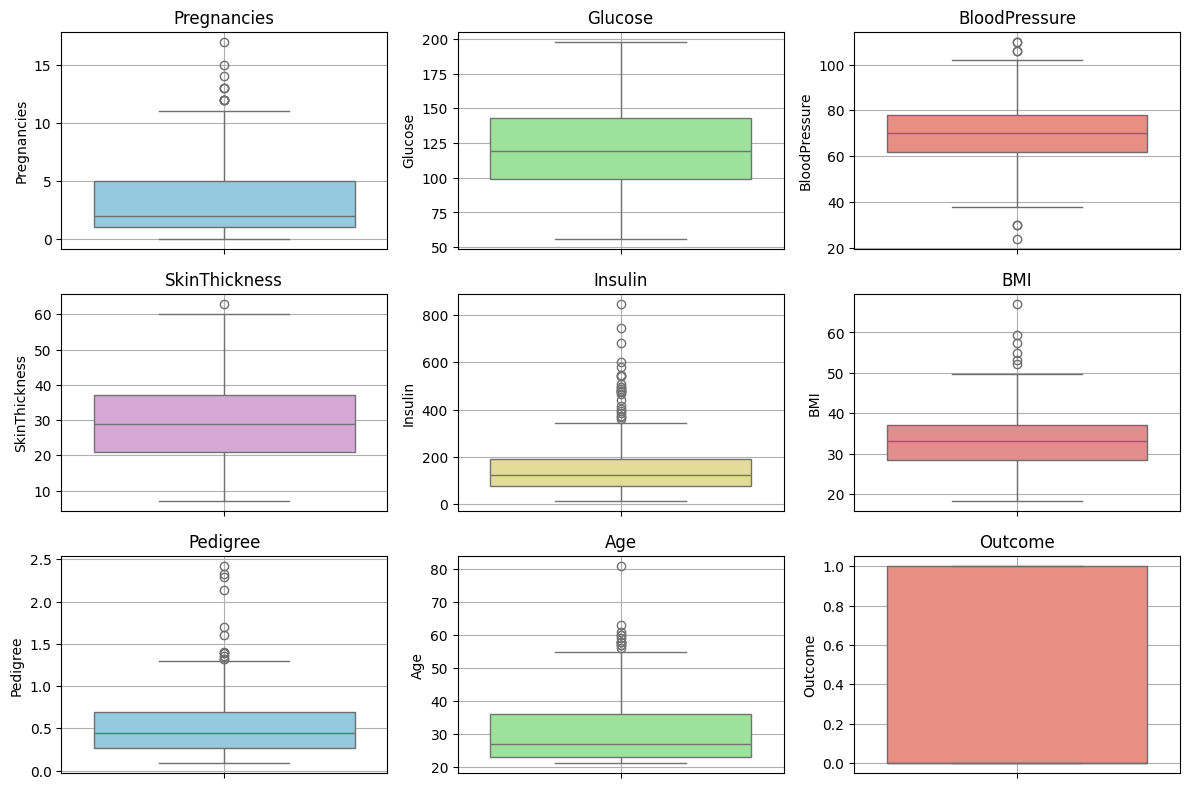

In [9]:
num_cols = len(df.columns)
cols_per_row = 3

fig, axes = plt.subplots(3, cols_per_row, figsize=(12, 8))
axes = axes.flatten() if num_cols > 1 else [axes]

colors = ["skyblue", "lightgreen", "salmon", "plum", "khaki", "lightcoral"]

for i, col in enumerate(list(df.columns)):
  sns.boxplot(y=df[col], ax=axes[i], color=colors[i % len(colors)])
  axes[i].set_title(col)
  axes[i].grid(True)

plt.tight_layout()
plt.show()

Видны выбросы, но не ограничиваем их так как это может сделать данные невалидными

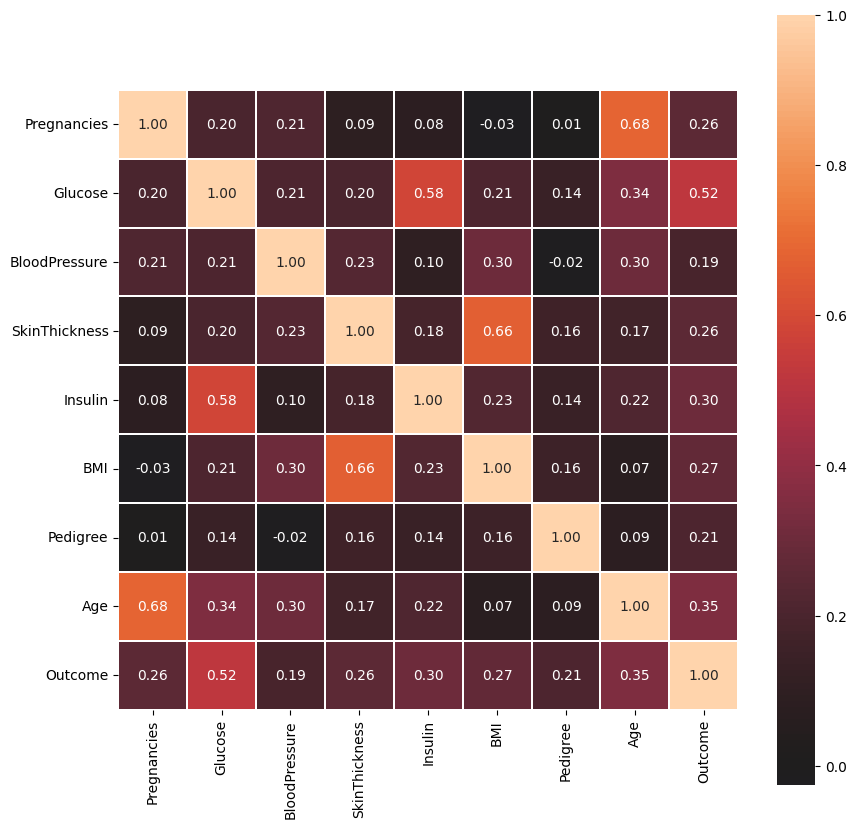

In [10]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", center=0,
            square=True, linewidths=0.1)
plt.show()

Теперь нормализуем данные с помощью min-max нормализации:

$$
x_{norm} = \frac{x-x_{min}}{x_{max}-x_{min}}
$$

In [11]:
n_df = df.copy()

for col in df:
  min_v = df[col].min()
  max_v = df[col].max()
  if min_v == max_v:
      continue
  n_df[col] = (df[col] - min_v) / (max_v - min_v)

n_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
3,0.058824,0.232394,0.488372,0.285714,0.096154,0.202454,0.035118,0.000000,0.0
4,0.000000,0.570423,0.186047,0.500000,0.185096,0.509202,0.943469,0.200000,1.0
6,0.176471,0.154930,0.302326,0.446429,0.088942,0.261759,0.069807,0.083333,1.0
8,0.117647,0.992958,0.534884,0.678571,0.635817,0.251534,0.031263,0.533333,1.0
13,0.058824,0.936620,0.418605,0.285714,1.000000,0.243354,0.134047,0.633333,1.0
...,...,...,...,...,...,...,...,...,...
753,0.000000,0.880282,0.744186,0.660714,0.596154,0.513292,0.058672,0.083333,1.0
755,0.058824,0.507042,0.744186,0.571429,0.115385,0.374233,0.416274,0.266667,1.0
760,0.117647,0.225352,0.395349,0.339286,0.002404,0.208589,0.291649,0.016667,0.0
763,0.588235,0.316901,0.604651,0.732143,0.199519,0.300613,0.036831,0.700000,0.0


Выделим из общего массива данных матрицу признаков и целевую колонку

In [12]:
X = n_df.drop('Outcome', axis=1)
Y = n_df['Outcome']

Реализуем функцию для разделения данных на тренировочную и тестовую выборки

In [13]:
def train_test_split(X, Y, seed=42, test_percent=0.2):
  random.seed(seed)
  random.shuffle(list(range(len(X))))

  test_size = int(len(X) * test_percent)

  x_train = X[test_size:]
  x_test = X[:test_size]
  y_train = Y[test_size:]
  y_test = Y[:test_size]

  return x_train, x_test, y_train, y_test

Разделим данные на обучающую и тестовую выборки

In [14]:
x_train, x_test, y_train, y_test = train_test_split(X, Y)

Реализуем логистивескую регрессию

In [15]:
class LogisticRegression:
  def __init__(self, learning_rate=0.01, num_iterations=1000, optimizer='gd'):
    self.learning_rate = learning_rate
    self.num_iterations = num_iterations
    self.weights = None
    self.optimizer = optimizer

  def sigmoid(self, z):
    return 1 / (1 + np.exp(-z))

  def loss(self, p, y):
    loss_ = -(y * np.log(p) + (1 - y) * np.log(1 - p))
    return np.mean(loss_)

  def gradient(self, x, y, n):
    p = self.sigmoid(np.dot(x, self.weights))
    return (1 / n) * np.dot(x.T, (p - y))

  def gradient_descent(self, x, y, n):
    dw = self.gradient(x, y, n)
    self.weights -= self.learning_rate * dw

  def newton_method(self, x, y, n):
    p = self.sigmoid(np.dot(x, self.weights))
    R = np.diag(p * (1 - p))
    H = (1 / n) * np.dot(x.T, np.dot(R, x))
    grad = self.gradient(x, y, n)
    H_inv = np.linalg.inv(H)
    delta = np.dot(H_inv, grad)
    self.weights -= delta

  def fit(self, x, y):
    n_samples, n_features = x.shape
    x_extended = np.c_[np.ones((n_samples, 1)), x]
    self.weights = np.zeros(n_features + 1)

    loss_history = []
    p = self.sigmoid(np.dot(x_extended, self.weights))
    _loss = self.loss(p, y)
    loss_history.append(_loss)

    for i in range(self.num_iterations):
      if (self.optimizer == 'gd'):
        self.gradient_descent(x_extended, y, n_samples)

      if (self.optimizer == 'newton'):
        self.newton_method(x_extended, y, n_samples)

      p = self.sigmoid(np.dot(x_extended, self.weights))
      _loss = self.loss(p, y)
      loss_history.append(_loss)

    return loss_history

  def predict(self, x):
    x_extended = np.c_[np.ones((x.shape[0], 1)), x]
    linear_model = np.dot(x_extended, self.weights)
    y_predicted = self.sigmoid(linear_model)
    y_predicted_class = (y_predicted > 0.5).astype(int)
    return y_predicted_class

Также введём функцию для рассчета основных метрик модели

In [16]:
def calculate_metrics(y_pred, y_test):
  TP = np.sum((y_pred == 1) & (y_test == 1))
  TN = np.sum((y_pred == 0) & (y_test == 0))
  FP = np.sum((y_pred == 1) & (y_test == 0))
  FN = np.sum((y_pred == 0) & (y_test == 1))

  accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) != 0 else 0
  precision = TP / (TP + FP) if (TP + FP) != 0 else 0
  recall = TP / (TP + FN) if (TP + FN) != 0 else 0
  f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0

  return {'accuracy': accuracy, 'precision': precision,  'recall': recall, 'f1': f1_score}

Задади вспомогательную функцию для проведение цикла обучения модели на определенных параметрах, и вывода метрик

In [17]:
def explore(learning_rate, num_iterations, optimizer):
  model =  LogisticRegression(learning_rate, num_iterations, optimizer)
  loss_history = model.fit(x_train, y_train)
  y_pred = model.predict(x_test)

  plt.plot(loss_history)
  plt.xlabel('Iteration')
  plt.ylabel('Loss')
  plt.title('Loss over iterations')
  plt.show()

  metrics = calculate_metrics(y_pred, y_test)
  for key, value in metrics.items():
      print(f"{key}: {value}")

Попробуем натренировать модель используя оптимизацию градиентным спуском

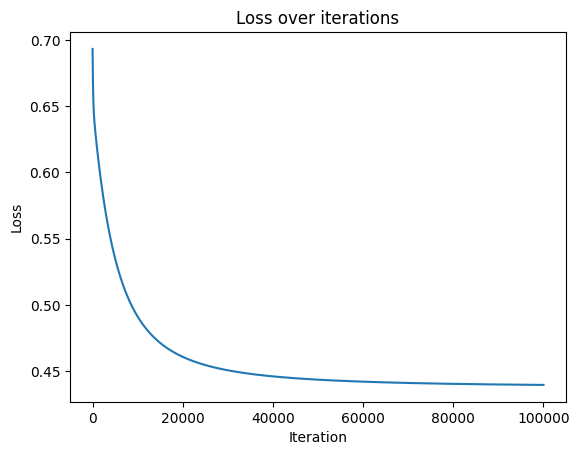

accuracy: 0.8333333333333334
precision: 0.8260869565217391
recall: 0.6785714285714286
f1: 0.7450980392156864


In [18]:
explore(learning_rate=0.01, num_iterations=100000, optimizer='gd')

Теперь попробуем метод Ньютона

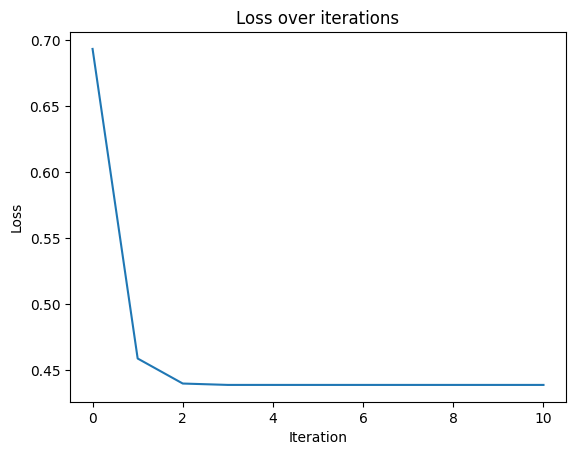

accuracy: 0.8333333333333334
precision: 0.8260869565217391
recall: 0.6785714285714286
f1: 0.7450980392156864


In [19]:
explore(learning_rate=0.01, num_iterations=10, optimizer='newton')

Попробуем также подобрать оптимальный набор параметров

In [20]:
n_iters = np.arange(2, 300, 10)
lr = np.arange(0.001, 0.01, 0.003)
optimizer = ['gd', 'newton']

best_params_ac = {}
best_params_pre = {}
best_params_re = {}
best_params_f1 = {}
best_accuracy_score = 0
best_precision_score = 0
best_recall_score = 0
best_f1_score = 0

i = 0
for n_iter in n_iters:
  for lr_ in lr:
    for opt in optimizer:
      clf = LogisticRegression(learning_rate=lr_, num_iterations=n_iter, optimizer=opt)
      clf.fit(x_train, y_train)
      predictions = clf.predict(x_test)
      metrics = calculate_metrics(predictions, y_test)

      if metrics['accuracy'] > best_accuracy_score:
          best_accuracy_score = metrics['accuracy']
          best_params_ac  = {'n_iter': n_iter, 'lr': lr_, 'optimizer': opt}

      if metrics['precision'] > best_precision_score:
          best_precision_score = metrics['precision']
          best_params_pre = {'n_iter': n_iter, 'lr': lr_, 'optimizer': opt}

      if metrics['recall'] > best_recall_score:
          best_recall_score = metrics['recall']
          best_params_re = {'n_iter': n_iter, 'lr': lr_,  'optimizer': opt}

      if metrics['f1'] > best_f1_score:
          best_f1_score = metrics['f1']
          best_params_f1 = {'n_iter': n_iter, 'lr': lr_, 'optimizer': opt}
      i += 1

print(f"Best accuracy score: {best_accuracy_score}, params: {best_params_ac}")
print(f"Best precision score: {best_precision_score}, params: {best_params_pre}")
print(f"Best recall score: {best_recall_score}, params: {best_params_re}")
print(f"Best f1 score: {best_f1_score}, params: {best_params_f1}")

Best accuracy score: 0.8333333333333334, params: {'n_iter': np.int64(2), 'lr': np.float64(0.001), 'optimizer': 'newton'}
Best precision score: 0.8260869565217391, params: {'n_iter': np.int64(2), 'lr': np.float64(0.001), 'optimizer': 'newton'}
Best recall score: 0.6785714285714286, params: {'n_iter': np.int64(2), 'lr': np.float64(0.001), 'optimizer': 'newton'}
Best f1 score: 0.7450980392156864, params: {'n_iter': np.int64(2), 'lr': np.float64(0.001), 'optimizer': 'newton'}
